In [32]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Users\axel_\Documents\conda\libertadores\matchStats\csv\fotmob_match_stats.csv')
df.head()

,matchId,matchRound,homeTeamName,homeTeamid,awayTeamName,awayTeamid,home_goals,away_goals,ball_possession_home,ball_possession_away,...,ground_duels_won_home,ground_duels_won_away,aerial_won_home,aerial_won_away,dribbles_succeeded_home,dribbles_succeeded_away,yellow_cards_home,yellow_cards_away,red_cards_home,red_cards_away
0,5261475,1,Deportivo La Guaira,176496,Fluminense,9863,0,0,36,64,...,23 (49%),24 (51%),12 (57%),9 (43%),5 (56%),3 (60%),4,0,0,0
1,5261551,1,Independiente Rivadavia,161729,Bolivar,5983,1,0,36,64,...,17 (32%),36 (68%),6 (43%),8 (57%),5 (42%),10 (71%),1,0,0,1
2,5261554,1,Always Ready,805913,LDU de Quito,6721,0,1,62,38,...,19 (43%),25 (57%),11 (44%),14 (56%),3 (33%),5 (63%),3,4,0,0
3,5261552,1,Barcelona SC,6453,Cruzeiro,9781,0,1,55,45,...,24 (40%),36 (60%),23 (52%),21 (48%),6 (67%),8 (67%),1,2,0,0
4,5261533,1,Universidad Catolica,6458,Boca Juniors,10077,1,2,45,55,...,35 (55%),29 (45%),11 (52%),10 (48%),6 (67%),6 (38%),4,2,0,0


In [21]:
df.columns

Index(['matchId', 'matchRound', 'homeTeamName', 'homeTeamid', 'awayTeamName',
       'awayTeamid', 'home_goals', 'away_goals', 'ball_possession_home',
       'ball_possession_away', 'big_chances_home', 'big_chances_away',
       'big_chances_missed_home', 'big_chances_missed_away', 'fouls_home',
       'fouls_away', 'corners_home', 'corners_away', 'total_shots_home',
       'total_shots_away', 'shots_off_target_home', 'shots_off_target_away',
       'shots_on_target_home', 'shots_on_target_away', 'blocked_shots_home',
       'blocked_shots_away', 'hit_woodwork_home', 'hit_woodwork_away',
       'shots_inside_box_home', 'shots_inside_box_away',
       'shots_outside_box_home', 'shots_outside_box_away', 'xG_home',
       'xG_away', 'xG_open_play_home', 'xG_open_play_away', 'xG_set_play_home',
       'xG_set_play_away', 'xG_non_penalty_home', 'xG_non_penalty_away',
       'xGOT_home', 'xGOT_away', 'passes_home', 'passes_away',
       'accurate_passes_home', 'accurate_passes_away', 'own_ha

In [26]:
# group by match round
df.groupby('matchRound')['away_goals'].sum()

matchRound
1    13
2    15
3    14
4     9
5    17
Name: away_goals, dtype: int64

In [33]:
# group by match round for home and away goals
x = df.groupby('matchRound').agg(
    home_goals = ('home_goals', 'sum'),
    away_goals   = ('away_goals', 'sum')
).reset_index()

x

,matchRound,home_goals,away_goals
0,1,11,13
1,2,27,15
2,3,29,14
3,4,20,9
4,5,30,17


In [48]:
x['matchRound'].info()

<class 'pandas.Series'>
RangeIndex: 5 entries, 0 to 4
Series name: matchRound
Non-Null Count  Dtype
--------------  -----
5 non-null      int64
dtypes: int64(1)
memory usage: 172.0 bytes


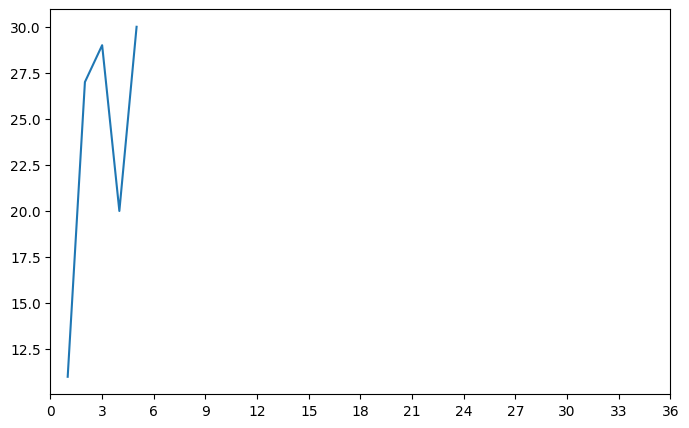

In [50]:
# line graph for home vs away goals by round
plt.figure(figsize=(8,5))

plt.plot(x.matchRound, x.home_goals)


# # Set ticks to whole numbers from min to max round
# min_round = int(min(x.matchRound))
# max_round = int(max(x.matchRound))
# plt.xticks(ticks=range(min_round, max_round + 1))

# Another alternative: from 0 to max shots + 5
max_shots = max(df.total_shots_home.max(), df.total_shots_away.max())
plt.xticks(range(0, max_shots + 5, 3)) # plt.yticks(range(start, stop, step))
plt.show()